In [1]:
install.packages("psych")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’




In [2]:
install.packages("factoextra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘plyr’, ‘abind’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘reshape2’, ‘ggrepel’




In [3]:
library(factoextra)

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



In [4]:
library(tidyverse)
library(psych)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha




In [6]:
df <- read.csv("wine_quality.csv" )%>% dplyr::select(-X)
df$quality_group <- cut(
  df$quality,
  breaks = c(-Inf, 3, 6, Inf),
  labels = c("Low", "Medium", "High"),
  right = TRUE
)
df <- df %>%
  select(-quality)

In [7]:
numeric_cols <- sapply(df, is.numeric)
df_numeric <- df[, numeric_cols]

pca_res <- principal(df_numeric, nfactors = ncol(df_numeric), rotate = "varimax", scores = TRUE, covar = FALSE)

In [8]:
prop_var <- pca_res$Vaccounted["Proportion Var", ]

col_order <- order(prop_var, decreasing = TRUE)

Vaccounted_sorted <- pca_res$Vaccounted[, col_order]

colnames(Vaccounted_sorted) <- paste0("RC", 1:ncol(Vaccounted_sorted))

Vaccounted_sorted

,RC1,RC2,RC3,RC4,RC5,RC6,RC7,RC8,RC9,RC10,RC11
SS loadings,1.6359214,1.5842168,1.1830482,1.1130329,1.06989719,1.04336695,1.04030473,1.00858991,0.97416840,0.30138027,0.046073244
Proportion Var,0.1487201,0.1440197,0.1075498,0.1011848,0.09726338,0.09485154,0.09457316,0.09168999,0.08856076,0.02739821,0.004188477
Cumulative Var,0.1487201,0.2927398,0.4002897,0.5014745,0.59873786,0.69358940,0.78816256,0.87985255,0.96841332,0.99581152,1.000000000
Proportion Explained,0.1487201,0.1440197,0.1075498,0.1011848,0.09726338,0.09485154,0.09457316,0.09168999,0.08856076,0.02739821,0.004188477
Cumulative Proportion,0.1487201,0.2927398,0.4002897,0.5014745,0.59873786,0.69358940,0.78816256,0.87985255,0.96841332,0.99581152,1.000000000


In [9]:
cum_var <- cumsum(Vaccounted_sorted[2,])
n_components <- which(cum_var >= 0.95)[1]

pca_final <- principal(df_numeric, nfactors = n_components, rotate = "varimax", scores = TRUE)

In [10]:
pca_final$Vaccounted

,RC1,RC2,RC6,RC8,RC4,RC7,RC3,RC9,RC5
SS loadings,1.8745757,1.5879487,1.1658441,1.09745866,1.06112866,1.04348882,1.04094760,0.96372854,0.95592873
Proportion Var,0.1704160,0.1443590,0.1059858,0.09976897,0.09646624,0.09486262,0.09463160,0.08761169,0.08690261
Cumulative Var,0.1704160,0.3147749,0.4207608,0.52052974,0.61699598,0.71185860,0.80649020,0.89410189,0.98100450
Proportion Explained,0.1737158,0.1471542,0.1080381,0.10170083,0.09833415,0.09669947,0.09646398,0.08930814,0.08858533
Cumulative Proportion,0.1737158,0.3208700,0.4289081,0.53060892,0.62894307,0.72564255,0.82210653,0.91141467,1.00000000


In [11]:
print(pca_final$loadings, cutoff = 0.3)


Loadings:
                     RC1    RC2    RC6    RC8    RC4    RC7    RC3    RC9   
fixed_acidity                              0.912                            
volatile_acidity                                                       0.885
citric_acid                                                     0.943       
residual_sugar                      0.908                                   
chlorides                                                                   
free_sulfur_dioxide   0.939                                                 
total_sulfur_dioxide  0.823                                                 
density                      0.692  0.519  0.340                            
pH                                                       0.952              
sulphates                                         0.963                     
alcohol                     -0.972                                          
                     RC5   
fixed_acidity              
volatile_

In [12]:
print(pca_final$communality)

       fixed_acidity     volatile_acidity          citric_acid 
           0.9941022            0.9988474            0.9961603 
      residual_sugar            chlorides  free_sulfur_dioxide 
           0.9928401            0.9927453            0.9440604 
total_sulfur_dioxide              density                   pH 
           0.9027021            0.9820429            0.9975113 
           sulphates              alcohol 
           0.9993384            0.9906990 


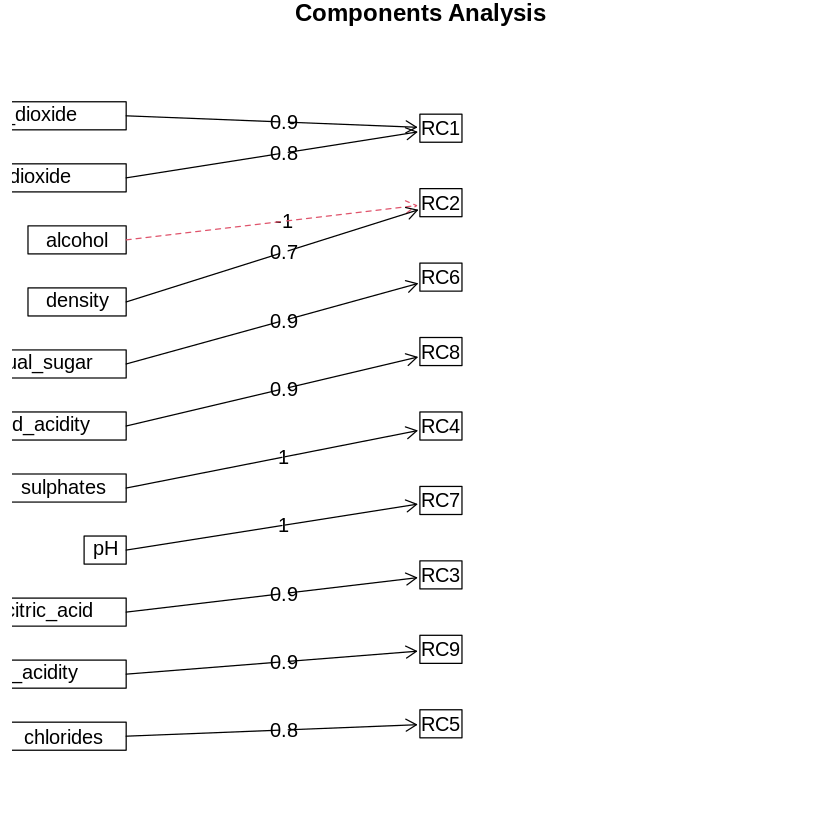

In [13]:
fa.diagram(pca_final)

In [21]:
for (component_name in colnames(pca_data_with_groups)[1:9]) {
  cat(paste0("\n\n--- Analyzing: ", component_name, " ---\n"))

  formula_str <- paste0(component_name, " ~ quality_group")
  aov_result <- aov(as.formula(formula_str), data = pca_data_with_groups)

  cat("ANOVA Summary:\n")
  print(summary(aov_result))

  p_value <- summary(aov_result)[[1]][["Pr(>F)"]][1]

  if (!is.na(p_value) && p_value < 0.05) {
    cat("\nANOVA is significant (p < 0.05). Performing TukeyHSD post-hoc test:\n")
    print(TukeyHSD(aov_result))
  } else {
    cat("\nANOVA is not significant (p >= 0.05). No post-hoc test needed.\n")
  }
}



--- Analyzing: RC1 ---
ANOVA Summary:
                Df Sum Sq Mean Sq F value Pr(>F)
quality_group    2      1  0.4592   0.459  0.632
Residuals     5981   5982  1.0002               

ANOVA is not significant (p >= 0.05). No post-hoc test needed.


--- Analyzing: RC2 ---
ANOVA Summary:
                Df Sum Sq Mean Sq F value Pr(>F)    
quality_group    2    937   468.3   555.1 <2e-16 ***
Residuals     5981   5046     0.8                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

ANOVA is significant (p < 0.05). Performing TukeyHSD post-hoc test:
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = as.formula(formula_str), data = pca_data_with_groups)

$quality_group
                   diff        lwr        upr     p adj
Medium-Low   0.09272753 -0.4836201  0.6690751 0.9245899
High-Low    -0.89283422 -1.4716588 -0.3140096 0.0008802
High-Medium -0.98556175 -1.0549101 -0.9162134 0.0000000



--- Analyzing: RC6 ---